# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import your TSV file called `Restaurant_Reviews.tsv`.  Note that TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [1]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


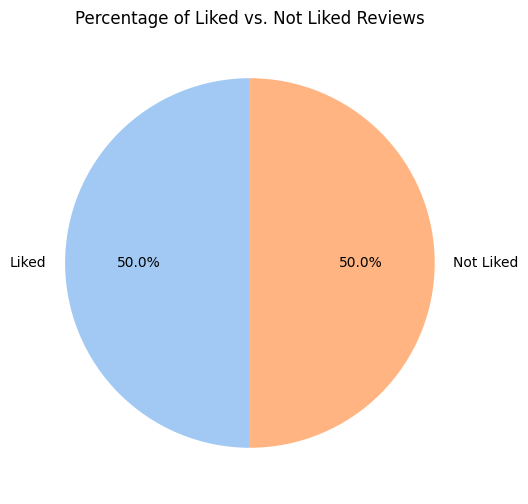

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for visualization
likes_count = df['Liked'].value_counts()
labels = ['Liked', 'Not Liked']
colors = sns.color_palette('pastel')[0:2]

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(likes_count, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Liked vs. Not Liked Reviews')
plt.show()

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

### In Your Response:
1. What risks might occur if you included the review "junk" in your model?


In [6]:
import re

def preprocess_review(text):
    # Ensure text is treated as a string and convert to lowercase
    text = str(text).lower()

    # Remove URLs (http/https links and www. links)
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)

    # Remove anything that isn't a regular character (a-z), number (0-9), or space.
    # This also effectively removes punctuation marks.
    text = re.sub(r'[^a-z0-9 ]', '', text)

    # Remove extra whitespace and strip leading/trailing whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply the preprocessing function to the 'Review' column
df['Review'] = df['Review'].apply(preprocess_review)

# Display the first few rows of the cleaned reviews to verify
print("First 5 cleaned reviews:")
print(df['Review'].head())

First 5 cleaned reviews:
0                                 wow loved this place
1                                    crust is not good
2             not tasty and the texture was just nasty
3    stopped by during the late may bank holiday of...
4    the selection on the menu was great and so wer...
Name: Review, dtype: object


1. Some risks that might occur if I include junk in the model would be that it can introduce noise, increase data dimensionality, and lead to inaccurate predictions.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%

### In Your Response:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)


In [7]:
# Install vaderSentiment if not already installed
!pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER sentiment intensity analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment scores
def get_vader_sentiment(text):
    vs = analyzer.polarity_scores(text)
    return vs

# Apply sentiment analysis to the 'Review' column
df['vader_sentiment'] = df['Review'].apply(get_vader_sentiment)

# Extract compound, positive, neutral, and negative scores
df['vader_compound'] = df['vader_sentiment'].apply(lambda x: x['compound'])
df['vader_pos'] = df['vader_sentiment'].apply(lambda x: x['pos'])
df['vader_neu'] = df['vader_sentiment'].apply(lambda x: x['neu'])
df['vader_neg'] = df['vader_sentiment'].apply(lambda x: x['neg'])

# Categorize sentiment based on compound score
def categorize_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_sentiment_category'] = df['vader_compound'].apply(categorize_sentiment)

# Calculate percentages for each category
sentiment_counts = df['vader_sentiment_category'].value_counts()
total_reviews = len(df)

percentage_positive = (sentiment_counts.get('Positive', 0) / total_reviews) * 100
percentage_negative = (sentiment_counts.get('Negative', 0) / total_reviews) * 100
percentage_neutral = (sentiment_counts.get('Neutral', 0) / total_reviews) * 100

print(f"Percentage of Positive reviews: {percentage_positive:.2f}%")
print(f"Percentage of Negative reviews: {percentage_negative:.2f}%")
print(f"Percentage of Neutral reviews: {percentage_neutral:.2f}%")

# Display the first few rows with new sentiment columns
print("\nFirst 5 rows with VADER sentiment scores:")
print(df[['Review', 'vader_compound', 'vader_sentiment_category']].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.2 MB/s eta 0:00:00
Percentage of Positive reviews: 50.60%
Percentage of Negative reviews: 25.50%
Percentage of Neutral reviews: 23.90%

First 5 rows with VADER sentiment scores:
                                              Review  vader_compound  \
0                               wow loved this place          0.8271   
1                                  crust is not good         -0.3412   
2           not tasty and the texture was just nasty         -0.5574   
3  stopped by during the late may bank holiday of...          0.6908   
4  the selection on the menu was great and so wer...          0.6249   

  vader_sentiment_category  
0                 Positive  
1                 Negative  
2                 Negative  
3                 Positive  
4                 Positive  


1. The VADER positive sentiment is very similar to the 'liked' percentage, suggesting a strong alignment between the two metrics.
2. From a restaurant owner's perspective, negative and neutral sentiment reviews would be more important to analyze as they directly highlight areas for improvement.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

### In Your Response:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?


In [9]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data (only run once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab') # Added to resolve LookupError

# Initialize lemmatizer and load stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_for_topic_modeling(text):
    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    processed_tokens = []
    for word in tokens:
        if word not in stop_words:
            processed_tokens.append(lemmatizer.lemmatize(word))

    return processed_tokens

# Apply the preprocessing function to the 'Review' column
df['processed_review'] = df['Review'].apply(preprocess_for_topic_modeling)

# Display the first 10 processed reviews
print("First 10 processed reviews:")
for i, review in enumerate(df['processed_review'].head(10)):
    print(f"{i+1}: {review}")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


First 10 processed reviews:
1: ['wow', 'loved', 'place']
2: ['crust', 'good']
3: ['tasty', 'texture', 'nasty']
4: ['stopped', 'late', 'may', 'bank', 'holiday', 'rick', 'steve', 'recommendation', 'loved']
5: ['selection', 'menu', 'great', 'price']
6: ['getting', 'angry', 'want', 'damn', 'pho']
7: ['honeslty', 'didnt', 'taste', 'fresh']
8: ['potato', 'like', 'rubber', 'could', 'tell', 'made', 'ahead', 'time', 'kept', 'warmer']
9: ['fry', 'great']
10: ['great', 'touch']


1. A corpus is a large and structured set of texts used to study language patterns and features for analysis.
2. For the review "Wow...Loved this place.", the tokens would be 'wow', 'loved', 'this', and 'place'. That would be after converting to lowercase and removing punctuation.
3. Lemmatization reduces words to their base or dictionary form which helps in grouping different inflections of a word together to improve the accuracy of text analysis.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

### In Your Response:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

In [11]:
!pip install gensim
from gensim import corpora

# Create a dictionary from the processed reviews
dictionary = corpora.Dictionary(df['processed_review'])

# Create a bag-of-words corpus
corpus = [dictionary.doc2bow(review) for review in df['processed_review']]

# Display a summary of the dictionary and corpus
print(f"Number of unique tokens in the dictionary: {len(dictionary)}")
print(f"Number of documents in the corpus: {len(corpus)}")
print("\nFirst 5 documents in the corpus (bag-of-words representation):")
for i, doc in enumerate(corpus[:5]):
    print(f"Document {i+1}: {doc}")

print("\nExample of mapping from token ID to word (first 10 items):")
# Example to show the mapping from token ID to word
# dictionary.id2token returns a dictionary where keys are IDs and values are tokens
# We take items to show the first few mappings
for id_val, token_val in list(dictionary.items())[:10]:
    print(f"ID {id_val}: {token_val}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.2 MB/s eta 0:00:00
Number of unique tokens in the dictionary: 1839
Number of documents in the corpus: 1000

First 5 documents in the corpus (bag-of-words representation):
Document 1: [(0, 1), (1, 1), (2, 1)]
Document 2: [(3, 1), (4, 1)]
Document 3: [(5, 1), (6, 1), (7, 1)]
Document 4: [(0, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1)]
Document 5: [(16, 1), (17, 1), (18, 1), (19, 1)]

Example of mapping from token ID to word (first 10 items):
ID 0: loved
ID 1: place
ID 2: wow
ID 3: crust
ID 4: good
ID 5: nasty
ID 6: tasty
ID 7: texture
ID 8: bank
ID 9: holiday


1. A corpus is a large and structured collection of texts that provides the raw data for text analysis, allowing identification and statistics.
2. A dictionary maps each unique word to a numerical ID, acting as a vocabulary while a corpus is a list of documents where each document is represented as a bag of words based on the dictionary.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

### In Your Response:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


In [12]:
from gensim.models import LdaModel

# Select the number of topics
num_topics = 5

# Create the LDA model
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=100)

print("LDA Model created with 5 topics.")

LDA Model created with 5 topics.


1. You would want to use more than 5 topics when the existing topics are too broad or when you need more fine distinctions in order to uncover underlying themes in the data.
2. You would know if you have too many topics if the topics have similar dominant words or if they are too difficult to interpret.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

### In Your Response:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"


--- Topics and Top 10 Words ---
Topic 0: 0.021*"service" + 0.019*"place" + 0.011*"food" + 0.009*"star" + 0.008*"slow" + 0.008*"dont" + 0.007*"waited" + 0.006*"great" + 0.006*"quality" + 0.006*"would"
Topic 1: 0.017*"food" + 0.011*"amazing" + 0.009*"good" + 0.008*"restaurant" + 0.008*"also" + 0.008*"ever" + 0.007*"experience" + 0.007*"like" + 0.007*"best" + 0.006*"could"
Topic 2: 0.031*"great" + 0.029*"good" + 0.028*"food" + 0.023*"place" + 0.023*"service" + 0.010*"friendly" + 0.007*"nice" + 0.007*"eat" + 0.007*"staff" + 0.007*"way"
Topic 3: 0.030*"back" + 0.020*"go" + 0.015*"time" + 0.013*"place" + 0.010*"wont" + 0.010*"vega" + 0.009*"food" + 0.008*"first" + 0.008*"really" + 0.008*"one"
Topic 4: 0.018*"good" + 0.016*"food" + 0.013*"steak" + 0.013*"like" + 0.009*"really" + 0.008*"place" + 0.007*"probably" + 0.007*"one" + 0.006*"fry" + 0.006*"also"

--- Topic Frequencies (Number of Reviews per Topic) ---
dominant_topic
0    170
1    137
2    282
3    242
4    169
Name: count, dtype: int6

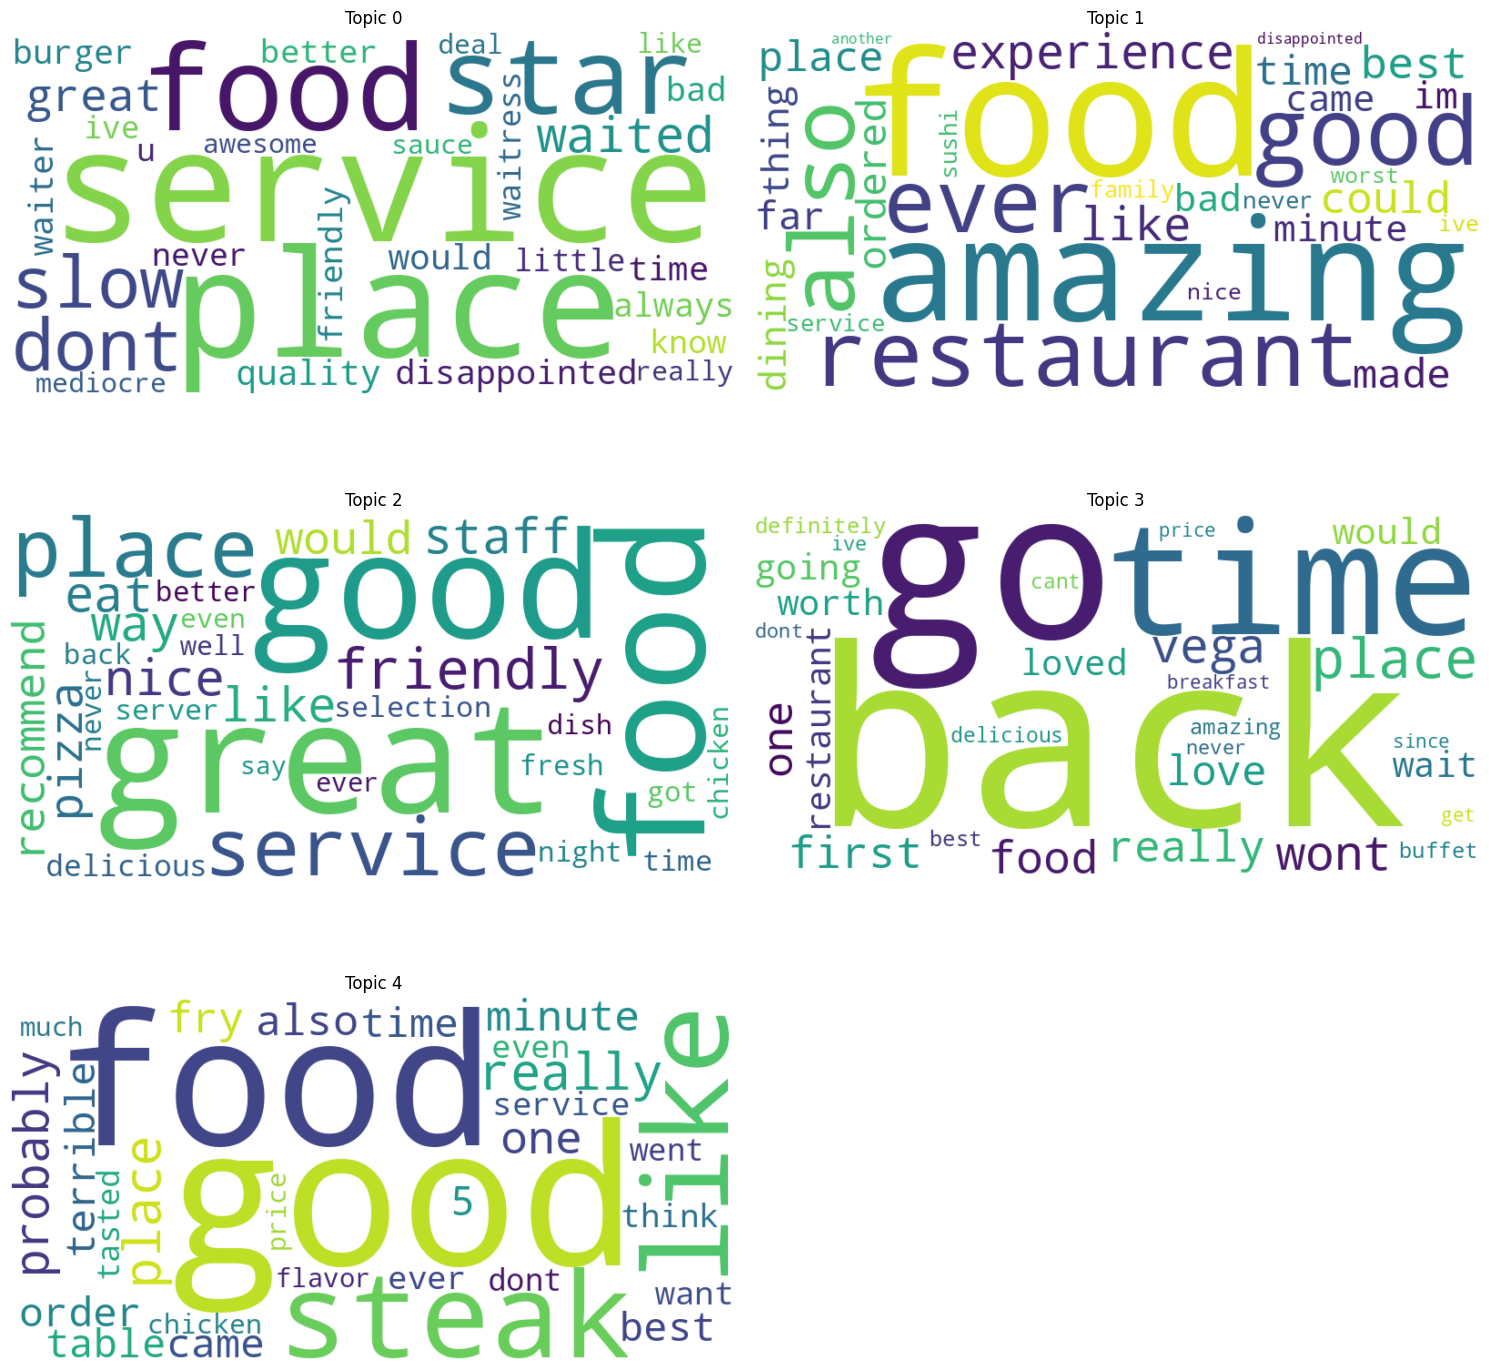


--- Sentiment Summary by Topic (Percentage) ---
vader_sentiment_category   Positive    Neutral   Negative
dominant_topic                                           
0                         34.705882  32.352941  32.941176
1                         51.824818  24.087591  24.087591
2                         63.829787  13.829787  22.340426
3                         50.000000  30.991736  19.008264
4                         44.378698  21.893491  33.727811


In [13]:
# 1. Print the topics and top 10 words in the topic
print("--- Topics and Top 10 Words ---")
topics = lda_model.print_topics(num_words=10)
for topic_id, topic_words in topics:
    print(f"Topic {topic_id}: {topic_words}")

# 2. Calculate the frequency of each topic
# Assign dominant topic to each review
dominant_topics = []
for i, row_list in enumerate(corpus):
    # Get all topic probabilities for the document
    topic_probabilities = lda_model.get_document_topics(row_list)
    # Find the topic with the highest probability
    if topic_probabilities:
        dominant_topic = max(topic_probabilities, key=lambda item: item[1])[0]
    else:
        dominant_topic = -1 # Assign a placeholder for documents with no topics
    dominant_topics.append(dominant_topic)

df['dominant_topic'] = dominant_topics

# Calculate topic frequencies
topic_frequency = df['dominant_topic'].value_counts(normalize=False).sort_index()
print("\n--- Topic Frequencies (Number of Reviews per Topic) ---")
print(topic_frequency)
print(f"Total reviews assigned to a topic: {topic_frequency.sum()}")
if -1 in topic_frequency.index:
    print(f"Reviews not assigned to any topic: {topic_frequency[-1]}")


# 3. Attempt at least one visual display of the topics (e.g., word cloud)
print("\n--- Generating Word Clouds for Each Topic ---")
import matplotlib.pyplot as plt

# Ensure 'wordcloud' is installed
try:
    from wordcloud import WordCloud
except ImportError:
    print("Installing wordcloud library...")
    !pip install wordcloud -qq
    from wordcloud import WordCloud

# Create a dictionary to store topic words with their probabilities
topic_words_dict = {}
for topic_id, topic_words in lda_model.show_topics(formatted=False, num_words=30):
    topic_words_dict[topic_id] = {word: prob for word, prob in topic_words}

num_topics_for_plot = len(topic_words_dict) # In case topic -1 was added
plt.figure(figsize=(15, 5 * ((num_topics_for_plot + 1) // 2)))

# Ensure we only plot actual topics, not the -1 placeholder
for i, topic_id in enumerate([t for t in topic_words_dict.keys() if t != -1]):
    wc = WordCloud(background_color="white", width=800, height=400, collocations=False).generate_from_frequencies(topic_words_dict[topic_id])
    plt.subplot((num_topics_for_plot + 1) // 2, 2, i + 1)
    plt.imshow(wc, interpolation="bilinear")
    plt.title(f'Topic {topic_id}')
    plt.axis("off")
plt.tight_layout()
plt.show()

# 4. Summarize the sentiment by topic
print("\n--- Sentiment Summary by Topic (Percentage) ---")
# Filter out documents not assigned to a valid topic (-1) before sentiment analysis
sentiment_by_topic = df[df['dominant_topic'] != -1].groupby('dominant_topic')['vader_sentiment_category'].value_counts(normalize=True).mul(100).unstack(fill_value=0)

# Reorder columns for better readability (Positive, Neutral, Negative), if they exist
ordered_cols = []
if 'Positive' in sentiment_by_topic.columns: ordered_cols.append('Positive')
if 'Neutral' in sentiment_by_topic.columns: ordered_cols.append('Neutral')
if 'Negative' in sentiment_by_topic.columns: ordered_cols.append('Negative')

sentiment_by_topic = sentiment_by_topic[ordered_cols] if ordered_cols else sentiment_by_topic

print(sentiment_by_topic)


1. Topic #0- Service and Quality, Topic #1- Amazing Food Experience, Topic #2- Great Food and Service, Topic #3- Return Intent and Experience, Topic #4- Food Dish Specifics

## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


1. The model helped identify the primary themes customers discuss in their reviews.
2. To improve customer satisfaction, the restaurant should focus on addressing issues related to service and quality.
3. Pros include faster initial setup and easier natural language. Cons involve less control over methodology and potential for higher operational costs.
4. "Analyze the provided restaurant reviews and summarize the overall sentiment of all reviews. For each identified topic, provide its top 5 keywords, the percentage of reviews falling into that topic, and the sentiment distribution within that topic. Then present the output in a structured format."

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [15]:
!jupyter nbconvert --to html "assignment_13_BensonDallin.ipynb"

[NbConvertApp] Converting notebook assignment_13_BensonDallin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 1338576 bytes to assignment_13_BensonDallin.html


# Task
Calculate the overall percentage of reviews where the 'Liked' column is 1 and visualize the percentage of liked versus non-liked reviews.

## Calculate Percentage of Liked Reviews

### Subtask:
Calculate the overall percentage of reviews where the 'Liked' column is 1.


**Reasoning**:
To calculate the percentage of liked reviews, I will count the occurrences where 'Liked' is 1, divide by the total number of reviews, and then multiply by 100.



In [2]:
total_reviews = len(df)
liked_reviews = df['Liked'].sum()
percentage_liked = (liked_reviews / total_reviews) * 100

print(f"Total number of reviews: {total_reviews}")
print(f"Number of liked reviews: {liked_reviews}")
print(f"Percentage of liked reviews: {percentage_liked:.2f}%")

Total number of reviews: 1000
Number of liked reviews: 500
Percentage of liked reviews: 50.00%


## Visualize Likes vs. Non-Likes

### Subtask:
Create a visualization (e.g., a bar chart or pie chart) to show the percentage of liked versus non-liked reviews.


## Summary:

### Q&A
*   **What is the overall percentage of reviews where the 'Liked' column is 1?**
    The overall percentage of reviews where the 'Liked' column is 1 is 50.00%.

### Data Analysis Key Findings
*   Out of a total of 1000 reviews, 500 reviews were marked as 'Liked'.
*   The percentage of liked reviews stands at 50.00%, meaning an equal proportion of reviews were not liked.

### Insights or Next Steps
*   Proceed with creating a visualization (e.g., a bar chart or pie chart) to clearly represent the 50% liked versus 50% non-liked review distribution, as indicated in the subtask.
